# Week 2 Assignment: Decomposition & Features
**DSE6230: Forecasting Methods and Applications**

Practice decomposing time series into Trend, Seasonal, and Residual components, and extracting features.

In [27]:
!pip install pandas numpy matplotlib statsmodels python-calamine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 919.5/919.5 kB 15.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import MSTL, seasonal_decompose
from statsmodels.tsa.tsatools import add_trend

## Part 1: Self-Guided Exercises

### Setup
We will use the `statsmodels` library for decomposition and the airline-passengers dataset for feature extraction.

In [ ]:
# Load airline data for decomposition
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
airline = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
airline.index.freq = 'MS'  # Monthly start

### Exercise 1.1: Classical Decomposition (Additive vs Multiplicative)
**Instruction**: Perform a **multiplicative** decomposition on the `airline` dataset. Store the result in `decomp_mult`. Notice how the seasonal component's magnitude varies with the trend.

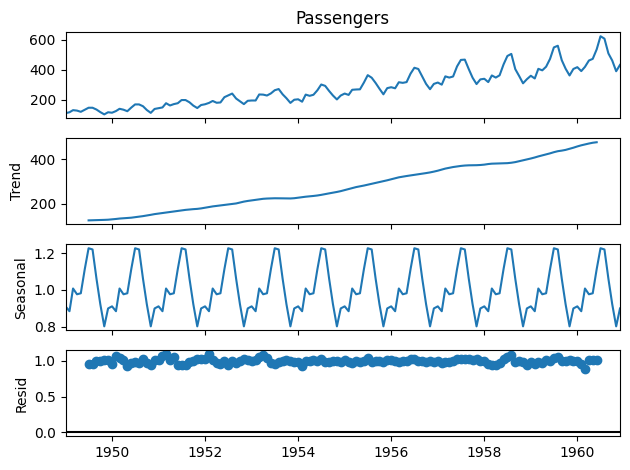

In [4]:
# Your Code Here
# decomp_mult = ...
decomp_mult = seasonal_decompose(airline['Passengers'], model='multiplicative', period=12)
decomp_mult.plot()
plt.show()

In [5]:
#| Check your work
try:
    assert 'decomp_mult' in locals(), "Variable 'decomp_mult' missing."
    assert decomp_mult.model == 'multiplicative', "Model should be multiplicative."
    print("Exercise 1.1 Passed!")
except Exception as e:
    print(f"Exercise 1.1 Failed: {e}")
# NOTE !!!! The checker checks both decomp_mult and decomp_mult.model - there's no decomp_mult.model to give it.

Exercise 1.1 Failed: 'DecomposeResult' object has no attribute 'model'


### Exercise 1.2: MSTL Decomposition
**Instruction**: The `airline` data has a clear monthly seasonality (period=12). Use `MSTL` from `statsmodels` to decompose the data. Store the result in `mstl_fit`.

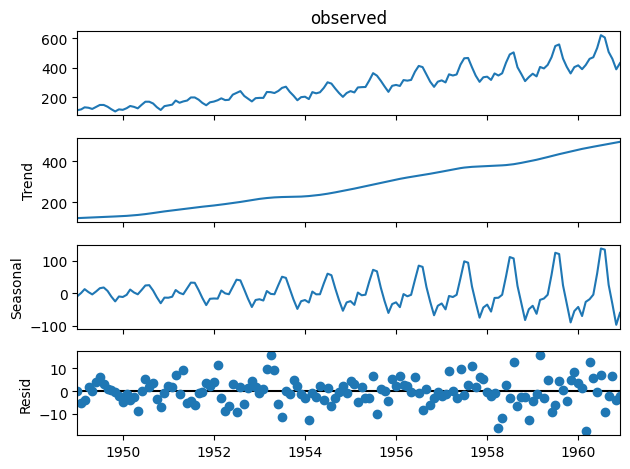

In [6]:
# Your Code Here
# mstl_fit = MSTL(airline['Passengers'], periods=(12,)).fit()
mstl_fit = MSTL(airline['Passengers'], periods=(12,)).fit()
mstl_fit.plot()
plt.show()

In [7]:
#| Check your work
try:
    assert 'mstl_fit' in locals(), "Variable 'mstl_fit' missing."
    assert hasattr(mstl_fit, 'seasonal'), "Result should have seasonal component."
    print("Exercise 1.2 Passed!")
except Exception as e:
    print(f"Exercise 1.2 Failed: {e}")

Exercise 1.2 Passed!


### Exercise 1.3: Feature Extraction (Strength of Trend)
**Instruction**: Calculate the "Strength of Trend" feature for the `airline` data using the `mstl_fit` result.
The formula is $F_T = \max\left(0, 1 - \frac{\text{Var}(R_t)}{\text{Var}(T_t + R_t)}\right)$, where $R_t$ is the remainder and $T_t$ is the trend.
Assign the result to `trend_strength`.

In [8]:
# Your Code Here
# trend = mstl_fit.trend
# resid = mstl_fit.resid
# trend_strength = ...
trend = mstl_fit.trend
resid = mstl_fit.resid

trend_strength = max(0, 1 - np.var(resid) / np.var(trend + resid))
trend_strength

0.9973020376764203

In [9]:
#| Check your work
try:
    assert 'trend_strength' in locals(), "Variable 'trend_strength' missing."
    assert 0 <= trend_strength <= 1, "Strength should be between 0 and 1."
    print(f"Exercise 1.3 Passed! Trend Strength: {trend_strength:.4f}")
except Exception as e:
    print(f"Exercise 1.3 Failed: {e}")

Exercise 1.3 Passed! Trend Strength: 0.9973


## Part 2: Textbook Exercises

Complete the following exercises from *Forecasting: Principles and Practice, the Pythonic Way*.

### Chapter 3: Time Series Decomposition

#### Question 3.1
> Consider the GDP information in `global_economy`. Plot the GDP per capita for each country over time. Which country has the highest GDP per capita? How has this changed over time?

#### Question 3.2
> For each of the following series, make a graph of the data. If transforming seems appropriate, do so and describe the effect: United States GDP from `global_economy`, Slaughter of Victorian "Bulls, bullocks and steers" from `aus_livestock`, Victorian Electricity Demand from `vic_elec`, and Gas production from `aus_production`.

#### Question 3.3
> Why is a Box-Cox transformation unhelpful for the `canadian_gas` data?

#### Question 3.4
> What Box-Cox transformation would you select for your retail data (from Exercise 7 in Section 2.10)?

#### Question 3.5
> For the following series, find an appropriate Box-Cox transformation to stabilise the variance: `Tobacco` from `aus_production`, `Economy` class passengers between Melbourne and Sydney from `ansett`, and `Pedestrian` counts at Southern Cross Station from `pedestrian`.

#### Question 3.6
> Consider the last five years of the Gas data from `aus_production`. Plot the time series. Use `seasonal_decompose` (multiplicative) to calculate trend-cycle and seasonal indices. Compute and plot seasonally adjusted data. Add an outlier and recompute.

#### Question 3.7
> Decompose your retail time series using the MSTL method. Does it reveal any outliers or unusual features?

#### Question 3.8
> Write about 3-5 sentences describing the results of the decomposition for the persons in the civilian labour force in Australia (Figures 3.13 and 3.14). Is the recession of 1991/1992 visible?

### Chapter 4: Time Series Features

#### Question 4.1
> Write a function to compute the mean and standard deviation of a time series and apply it to the `PBS` data. Plot the series with the highest mean and the series with the lowest standard deviation.

#### Question 4.2
> Use `sns.pairplot()` to look at the relationships between the STL-based features for the holiday series in the `tourism` data. Which is the peak quarter for holidays in each state?

#### Question 4.3
> Use a feature-based approach to look for outlying series in the `PBS` data. What is unusual about the series you identify?

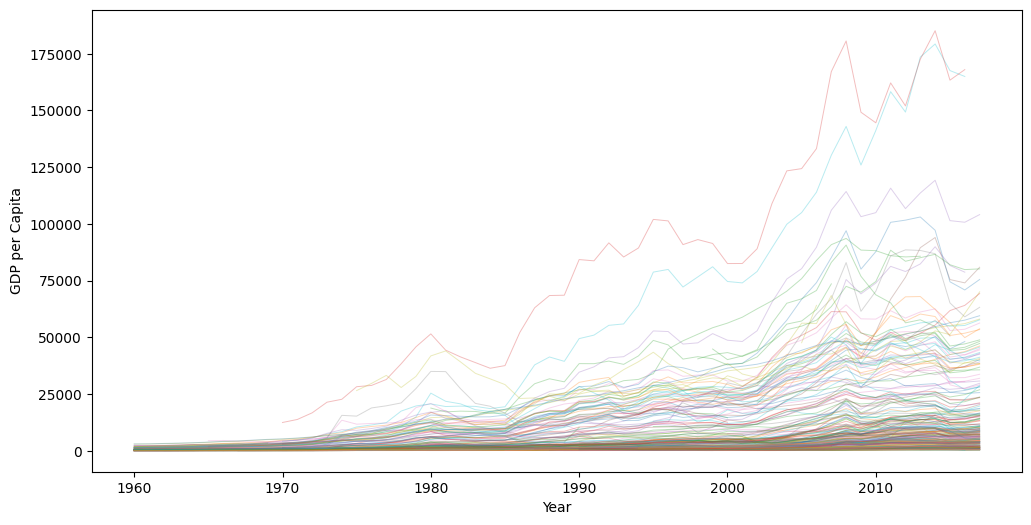

,unique_id,ds,GDP_per_Capita
9504,Monaco,2016,168010.914891
8112,Liechtenstein,2016,164993.194162
8403,Luxembourg,2017,104103.036747
1329,Bermuda,2013,85748.065414
8461,"Macao SAR, China",2017,80892.821329


In [12]:
# QUESTION 3.1

# READ IN GLOBAL ECONOMY
global_economy = pd.read_csv('global_economy.csv')
global_economy['GDP_per_Capita'] = global_economy['GDP'] / global_economy['Population']

# Create the graph
fig, ax = plt.subplots(figsize=(12, 6))
for country, group in global_economy.groupby('unique_id'):
    # For each country, add a line
    ax.plot(group['ds'], group['GDP_per_Capita'], alpha=0.3, linewidth=0.7)
ax.set_xlabel('Year')
ax.set_ylabel('GDP per Capita')
plt.show()

# Country with the highest GDP per capita, using each country's most recent available year
gdp_pc = global_economy.dropna(subset=['GDP_per_Capita'])
latest = gdp_pc.sort_values('ds').groupby('unique_id').tail(1)
# Display only the top 5
top5 = latest.sort_values('GDP_per_Capita', ascending=False).head(5)
top5[['unique_id', 'ds', 'GDP_per_Capita']]

# ANALYSIS:
# The top countries are Monaco, Lichtenstein, and Luxembourg. Each of these countries are small in population but with high tourism
# and generally wealthy individuals residing in the state. As can be seen, the actual GDP highly fluctuates by year, with no real
# steadiness as the values shift.

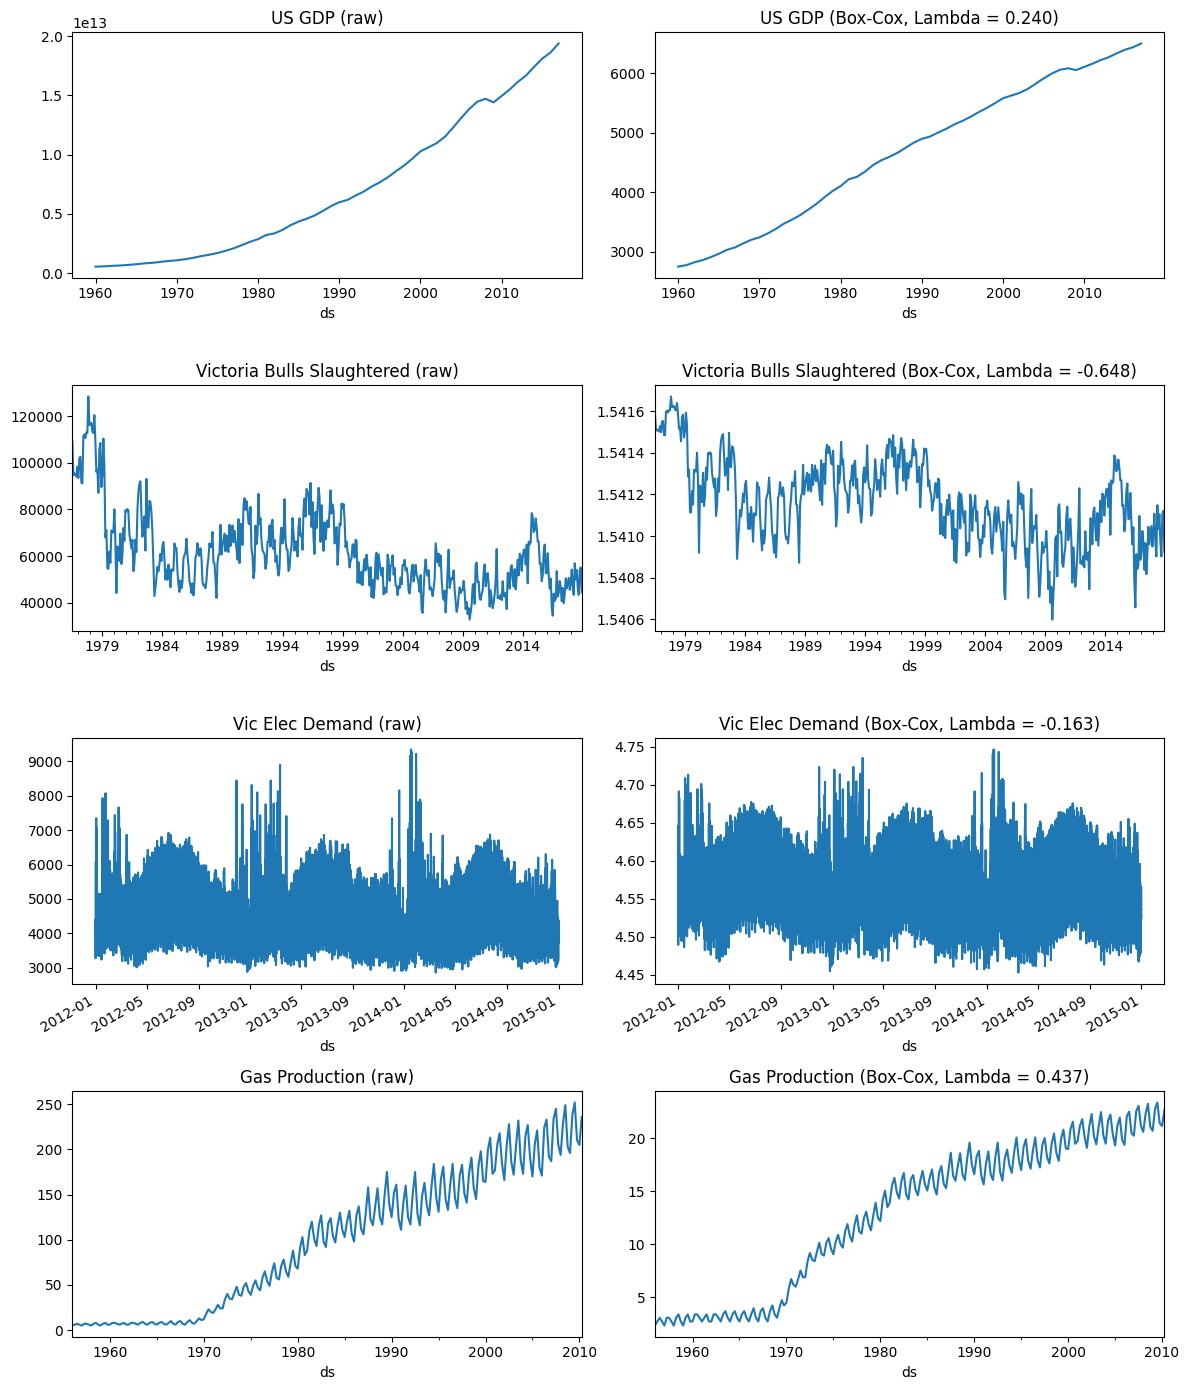

In [13]:
# QUESTION 3.2

# Import BoxCox specifically
from scipy.stats import boxcox

# 1. US GDP - No Change
us_gdp = global_economy[global_economy['unique_id'] == 'United States'].set_index('ds')['GDP'].dropna()

# 2. Victorian "Bulls, bullocks and steers" slaughter - Fix DateTime
aus_livestock = pd.read_csv('aus_livestock.csv')
aus_livestock['ds'] = pd.to_datetime(aus_livestock['ds'])
bulls = aus_livestock[aus_livestock['unique_id'] == 'Victoria_Bulls, bullocks and steers'].set_index('ds')['y'].sort_index()

# 3. Victorian Electricity Demand - Fix DateTime
vic_elec = pd.read_csv('vic_elec.csv')
vic_elec['ds'] = pd.to_datetime(vic_elec['ds'])
demand = vic_elec[vic_elec['unique_id'] == 'Demand'].set_index('ds')['y'].sort_index()

# 4. Gas Production - Fix DateTime
aus_production = pd.read_csv('aus_production.csv')
aus_production['ds'] = pd.to_datetime(aus_production['ds'])
aus_production = aus_production.set_index('ds')
gas = aus_production['Gas'].dropna()

# Collection of all Series
all_series = {'US GDP': us_gdp, 'Victoria Bulls Slaughtered': bulls, 'Vic Elec Demand': demand, 'Gas Production': gas}

# Create Graphs
fig, axes = plt.subplots(4, 2, figsize=(12, 14))
for row, (name, s) in enumerate(all_series.items()):
    transformed, lam = boxcox(s.values)
    s.plot(ax=axes[row, 0], title=f'{name} (raw)')
    pd.Series(transformed, index=s.index).plot(ax=axes[row, 1], title=f'{name} (Box-Cox, Lambda = {lam:.3f})')
plt.tight_layout()
plt.show()

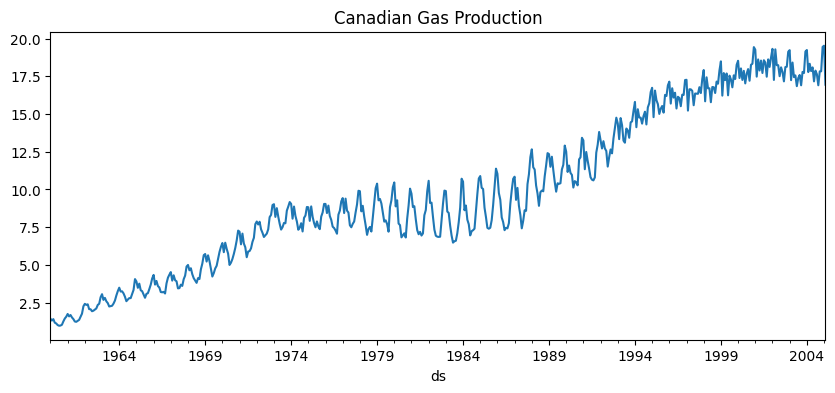

In [14]:
# QUESTION 3.2
canadian_gas = pd.read_csv('canadian_gas.csv')
canadian_gas['ds'] = pd.to_datetime(canadian_gas['ds'])

# Create the series
cg_series = canadian_gas.set_index('ds')['y'].sort_index()

# Plot the graph
cg_series.plot(figsize=(10, 4), title='Canadian Gas Production')
plt.show()

# ANALYSIS
# Box-Cox inherently assumes that there's some kind of monotonical change within the graph, with high variance at
# higher levels, and low variance at lower levels. Here, there's two sections of mostly linear growth (earliest and
# latest sections) but with a middlemost part that stagnates. There's no real way to stabilize the graph through
# one single transformation that Box-Cox can do.

Selected lambda: 0.1947


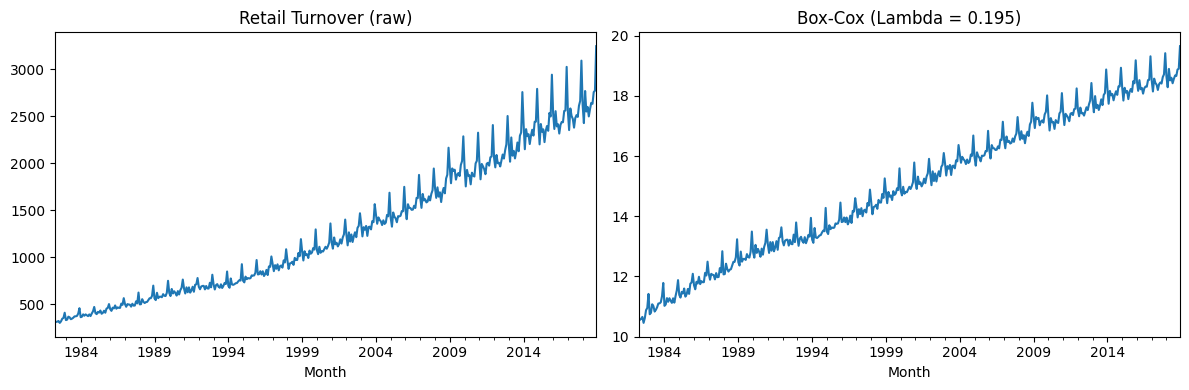

In [15]:
# QUESTION 3.4
# ORIGINAL DATA SET FOR RETAIL: Victoria, Food Retailing
aus_retail = pd.read_csv('aus_retail.csv')
aus_retail['Month'] = pd.to_datetime(aus_retail['Month'])

# Recreate the retail series
retail_series = aus_retail[(aus_retail['State'] == 'Victoria') & (aus_retail['Industry'] == 'Food retailing')
].set_index('Month')['Turnover'].sort_index()

# Create the BoxCox
transformed, lam_retail = boxcox(retail_series.values)
print(f'Selected lambda: {lam_retail:.4f}')

# Create the graph
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
retail_series.plot(ax=axes[0], title='Retail Turnover (raw)')
pd.Series(transformed, index=retail_series.index).plot(ax=axes[1], title=f'Box-Cox (Lambda = {lam_retail:.3f})')
plt.tight_layout()
plt.show()

# ANALYSIS
# Using BoxCox, compared to the original turnout, we see a much more normal growth pattern. Though we still see the ridges from the
# seasonality, we see a vastly more linear shape, with no small curve later. It makes our graph more easy to interpret, as well as
# reducing the severity of the spikes we see later that can be otherwise explained.

Tobacco Lambda:  1.4081158422710829
Ansett MEL-SYD Lambda:  1.2501376037023786
Pedestrian Lambda:  0.10366980539280612


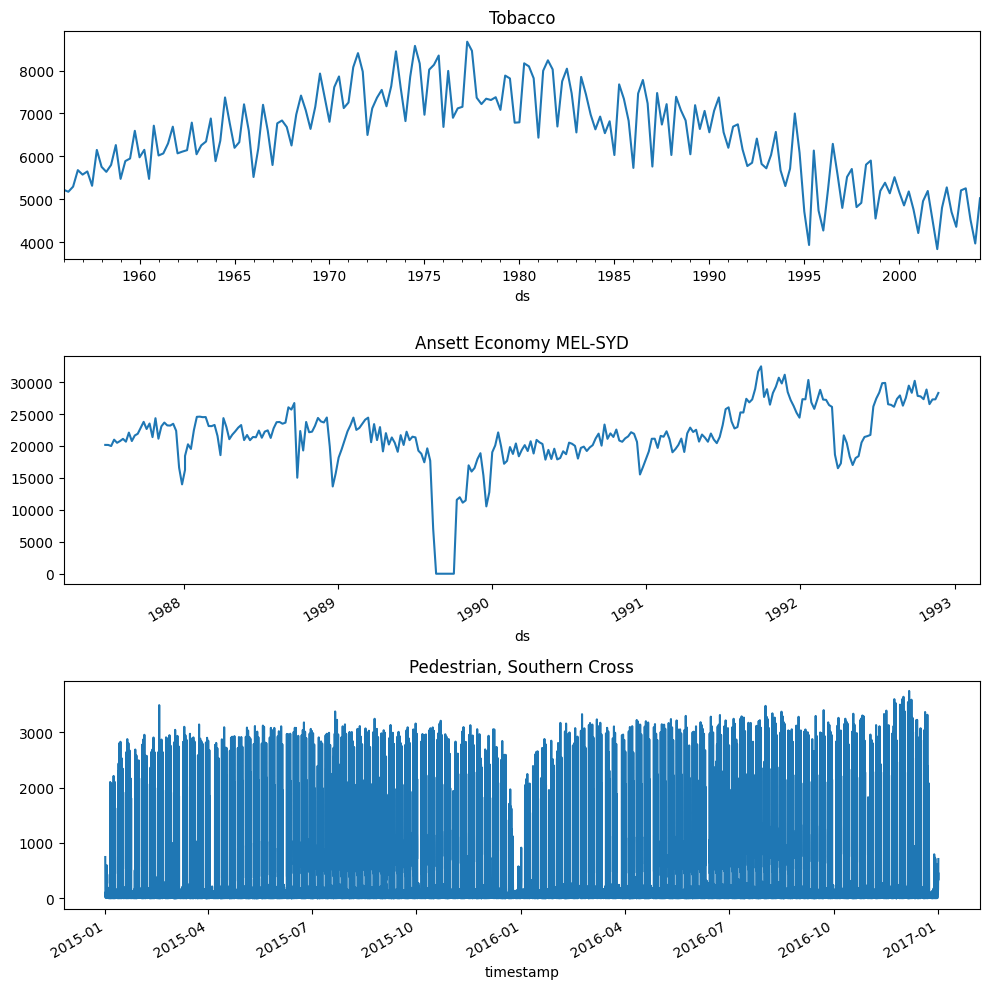

In [17]:
# QUESTION 3.5
# 1. Tobacco (aus_production)
tobacco = aus_production['Tobacco'].dropna()
_, lam_t = boxcox(tobacco.values)

# 2. Economy Passengers, Melbourne-Sydney (ansett)
ansett = pd.read_csv('ansett.csv')
# Fix DateTime
ansett['ds'] = pd.to_datetime(ansett['ds'])
econ_melsyd = ansett[
    (ansett['Airports'] == 'MEL-SYD') & (ansett['Class'] == 'Economy')
].set_index('ds')['y'].sort_index()
# Box-Cox does not work with 0-value weeks, so we remove all strike weeks.
econ_melsyd_nz = econ_melsyd[econ_melsyd > 0]
_, lam_a = boxcox(econ_melsyd_nz.values)

# 3. Pedestrian Counts at Southern Cross Station (pedestrian)
pedestrian = pd.read_csv('pedestrian.csv')
pedestrian['ds'] = pd.to_datetime(pedestrian['ds'])
pedestrian['timestamp'] = pedestrian['ds'] + pd.to_timedelta(pedestrian['Time'], unit='h')
scs = pedestrian[pedestrian['unique_id'] == 'Southern Cross Station'].set_index('timestamp')['y'].sort_index()
# As before, BoxCox does not work with 0-value hours, so those are all dropped too.
scs_nz = scs[scs > 0]
_, lam_p = boxcox(scs_nz.values)

print(f'Tobacco Lambda: ', lam_t)
print(f'Ansett MEL-SYD Lambda: ', lam_a,)
print(f'Pedestrian Lambda: ', lam_p)

# Make the plots
fig, axes = plt.subplots(3, 1, figsize=(10, 10))
tobacco.plot(ax=axes[0], title=f'Tobacco')
econ_melsyd.plot(ax=axes[1], title=f'Ansett Economy MEL-SYD')
scs.plot(ax=axes[2], title=f'Pedestrian, Southern Cross')
plt.tight_layout()

plt.show()

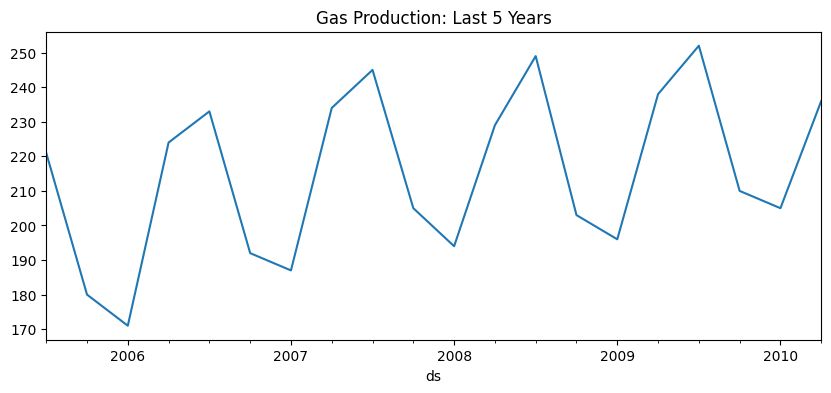

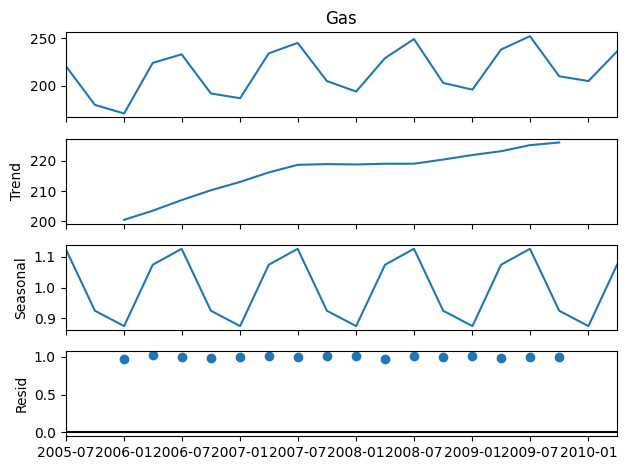

Seasonal Indices (By Quarter):
ds
2005-07-01    1.125681
2005-10-01    0.925066
2006-01-01    0.875282
2006-04-01    1.073971
Name: seasonal, dtype: float64


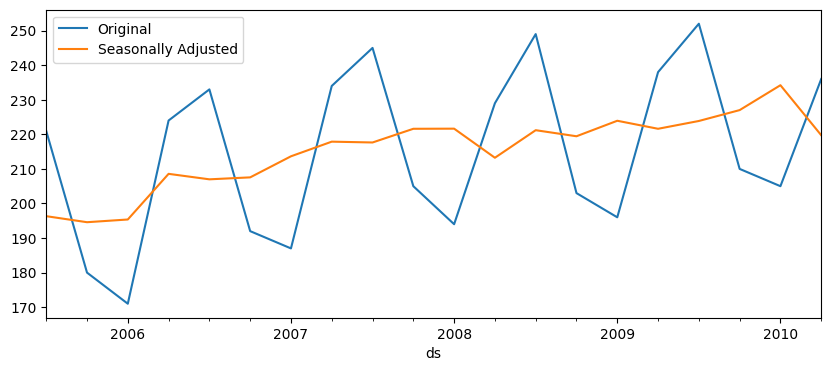

In [18]:
# QUESTION 3.6

# Isolate Gas
gas_full = aus_production['Gas'].dropna()
# Get just the last 5 years
gas_last5 = gas_full.loc[gas_full.index.max() - pd.DateOffset(years=5) + pd.DateOffset(days=1):]

# Plot the last 5 years
gas_last5.plot(figsize=(10, 4), title='Gas Production: Last 5 Years')
plt.show()

# Seasonal Decompisition
decomp_gas = seasonal_decompose(gas_last5, model='multiplicative', period=4)
decomp_gas.plot()
plt.show()

print('Seasonal Indices (By Quarter):')
print(decomp_gas.seasonal.iloc[:4])

# Seasonally-Adjusted Data
seasonally_adj = gas_last5 / decomp_gas.seasonal
fig, ax = plt.subplots(figsize=(10, 4))
gas_last5.plot(ax=ax, label='Original')
seasonally_adj.plot(ax=ax, label='Seasonally Adjusted')
ax.legend()
plt.show()

# ANALYSIS
# Seasonal readjustment significantly reduces the fluctuations in the graph. By adjusting for the
# decomposition, we still see a steady gas production increase like in the original graph, but now with
# more detail on *how* it's shifting within the graph. It is still affected by actual trends, and so
# is not perfectly linear, but it shows a vastly more regulated increase than the massive spikes seen before.

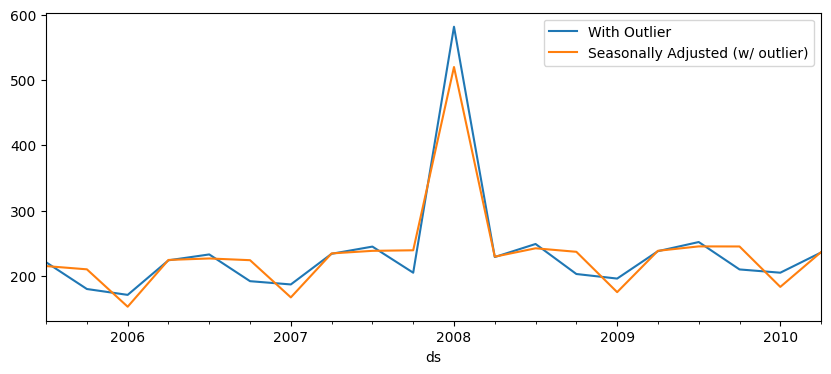

In [19]:
# QUESTION 3.6.1 - Outlier
# Copy the original graph before decomposition
gas_outlier = gas_last5.copy()
mid_point = gas_outlier.index[len(gas_outlier) // 2]
# Multiply by 3 -> creates a massive spike right in the middle.
gas_outlier.loc[mid_point] = gas_outlier.loc[mid_point] * 3

# Decomposition as before...
decomp_gas_outlier = seasonal_decompose(gas_outlier, model='multiplicative', period=4)
seasonally_adj_outlier = gas_outlier / decomp_gas_outlier.seasonal

# Plot our outlier data
fig, ax = plt.subplots(figsize=(10, 4))
gas_outlier.plot(ax=ax, label='With Outlier')
seasonally_adj_outlier.plot(ax=ax, label='Seasonally Adjusted (w/ outlier)')
ax.legend()
plt.show()

# ANALYSIS
# The addition of the outlier has completely ruined the benefits of seasonality decomp as seen before.
# Though decomp is capable of reducing the fluctuations caused by the repeated patterns, it's not able
# to effectively handle the egregiously high outlier added to the graph, and so fails to stabilize
# as well as we might otherwise hope.

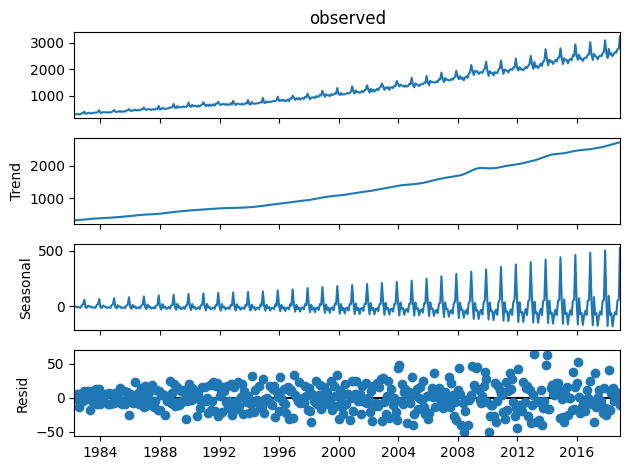

Potential outlier months (large MSTL residuals):
Month
2013-03-01    64.260305
2014-01-01    62.733437
Name: resid, dtype: float64


In [21]:
# QUESTION 3.7
# Copy our previous series
retail_series_freq = retail_series.copy()
# Set our frequency method
retail_series_freq.index.freq = 'MS'

# Decompose using MSTL and then plot
mstl_retail = MSTL(retail_series_freq, periods=(12,)).fit()
mstl_retail.plot()
plt.show()

# Flag points where the residual is unusually large
resid = mstl_retail.resid
threshold = 3 * resid.std()
# Collect all outliers
outliers = resid[resid.abs() > threshold]
print('Potential Outlier Months:')
print(outliers)

# ANALYSIS
# We receive two outliers, both of which can be seen in the residual chart quite well,
# alongside being captured by our threshold: March in 2013, and January in 2014. Both
# of these months had extraordinarily high residuals, which - though not corruptive
# on its own - is enough to warrant notice.

In [ ]:
# QUESTION 3.8
# (small correction - figures 3.15 and 3.16)

# When looking at the civilian labor force, we can see very clearly in the graphs where the recession is. It's much less visible
# within the value and trend graphs, where it's only a small waver in an otherwise continuous line, and completely invisible seasonally,
# but is **highly** visible in the remainder, where it is represented by a massive set of spikes and crashes. It is the only time that
# the value of a point goes below ~ -70 on the graph, reaching all the way down to the maximum loss of -200.

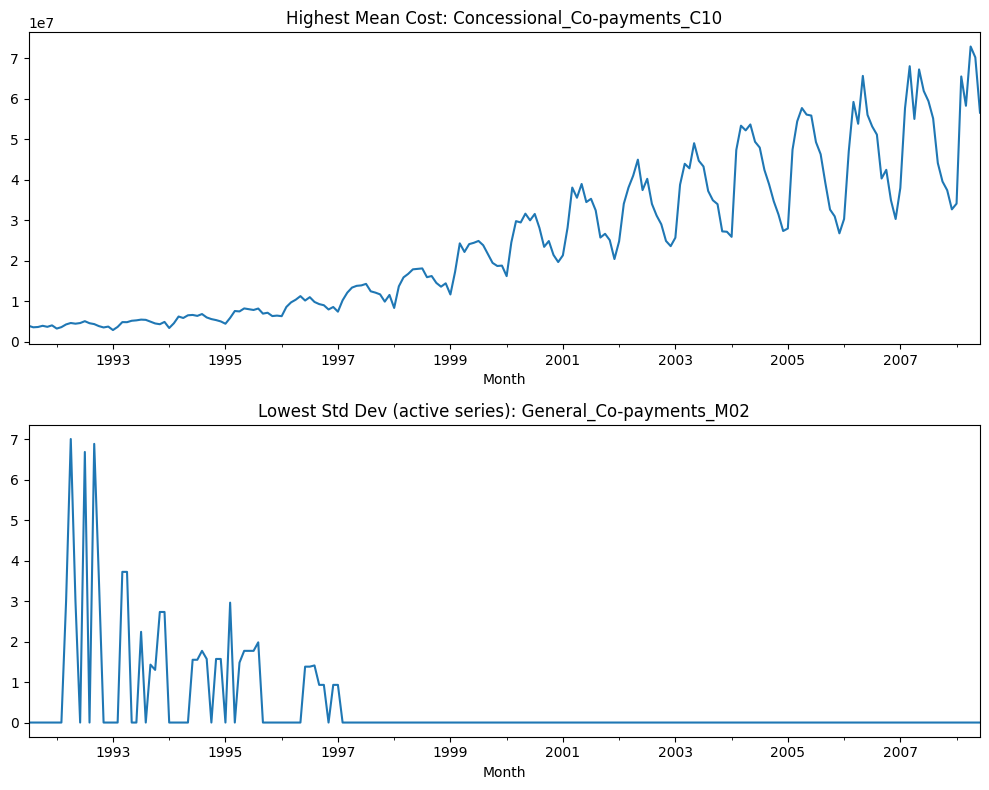

In [25]:
# QUESTION 4.1
# Read in PBS
pbs = pd.read_csv('pbs.csv')
# 'Sept' isn't a standard month abbreviation, so we normalize it
pbs['Month'] = pd.to_datetime(pbs['Month'].str.replace('Sept', 'Sep'), format='%Y %b')
# Break each section into its own unique ID.
pbs['series_id'] = pbs['Concession'] + '_' + pbs['Type'] + '_' + pbs['ATC2']

def mean_std(series):
    # Returns the mean and std of each series.
    return pd.Series({'mean': series.mean(), 'std': series.std()})

# Run through each entry and create the mean/std of each section
stats = pbs.groupby('series_id')['Cost'].apply(mean_std).unstack()

# Remove dead entries
active_stats = stats[stats['mean'] > 0]

# Find max mean and lowest std
highest_mean_id = stats['mean'].idxmax()
lowest_std_id = active_stats['std'].idxmin()

# Select those series in particular
highest_mean_series = pbs[pbs['series_id'] == highest_mean_id].groupby('Month')['Cost'].sum().sort_index()
lowest_std_series = pbs[pbs['series_id'] == lowest_std_id].groupby('Month')['Cost'].sum().sort_index()

# Plot the two graphs
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
highest_mean_series.plot(ax=axes[0], title=f'Highest Mean Cost: {highest_mean_id}')
lowest_std_series.plot(ax=axes[1], title=f'Lowest Std Dev (active series): {lowest_std_id}')
plt.tight_layout()
plt.show()


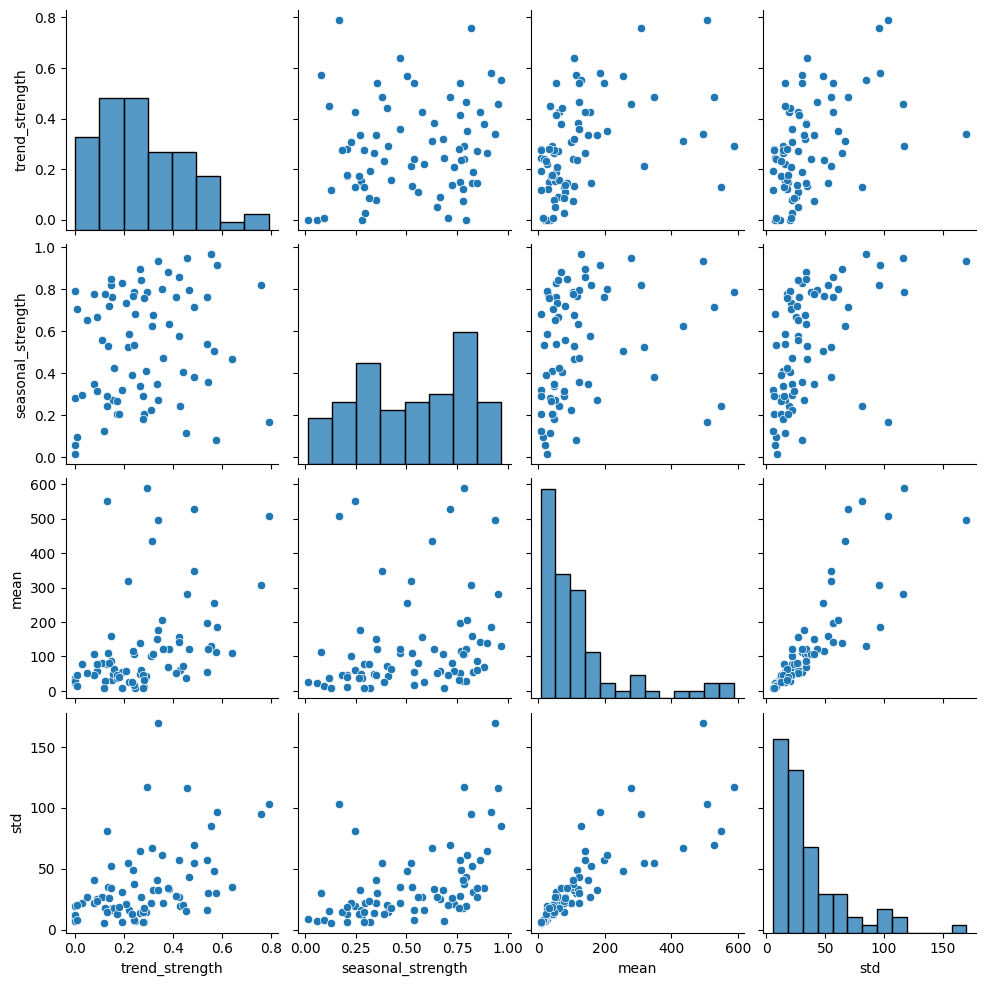

,State,QuarterNum,Trips
0,ACT,1,167.527771
4,New South Wales,1,269.007292
10,Northern Territory,3,46.622993
14,Queensland,3,193.865121
16,South Australia,1,65.909015
20,Tasmania,1,124.011650
24,Victoria,1,139.484606
28,Western Australia,1,179.679220


In [29]:
# QUESTION 4.2
import seaborn as sns
from statsmodels.tsa.seasonal import STL

# Read the Excel - using Calamine to avoid issues
tourism = pd.read_excel('tourism.xlsx', engine='calamine')
tourism['Quarter'] = pd.to_datetime(tourism['Quarter'])
holiday = tourism[tourism['Purpose'] == 'Holiday'].copy()

# Features bucket
features = []

# For each region...
for region, group in holiday.groupby('Region'):
    # ...break into groups
    s = group.set_index('Quarter')['Trips'].sort_index()
    # If pairs not filled, continue
    if len(s) < 8:
        continue
    # Infer the frequency
    s.index.freq = pd.infer_freq(s.index)
    # Fit to STL
    stl = STL(s, period=4, robust=True).fit()
    # Get the strength of each trend and seasonality
    trend, seasonal, resid = stl.trend, stl.seasonal, stl.resid
    trend_strength = max(0, 1 - np.var(resid) / np.var(trend + resid))
    seasonal_strength = max(0, 1 - np.var(resid) / np.var(seasonal + resid))
    # Add to bucket
    features.append({
        'Region': region, 'trend_strength': trend_strength,
        'seasonal_strength': seasonal_strength, 'mean': s.mean(), 'std': s.std()
    })

# Create the dataframe
feat_df = pd.DataFrame(features)
# Create the pairplot
sns.pairplot(feat_df[['trend_strength', 'seasonal_strength', 'mean', 'std']])
plt.show()

# Raw data outputs:
holiday['QuarterNum'] = holiday['Quarter'].dt.quarter
state_quarter_avg = holiday.groupby(['State', 'QuarterNum'])['Trips'].mean().reset_index()
peak_quarter = state_quarter_avg.loc[state_quarter_avg.groupby('State')['Trips'].idxmax()]
peak_quarter[['State', 'QuarterNum', 'Trips']].sort_values('State')

# ANALYSIS
# The best holiday quarters for most of Australia is during Q1, or Australia's summer, with the exception of Queensland and
# Northern Territory, which has it during Q3, Australia's winter. This is likely due to summer break for school for Q1, and
# to escape the bitter winters during Q3.

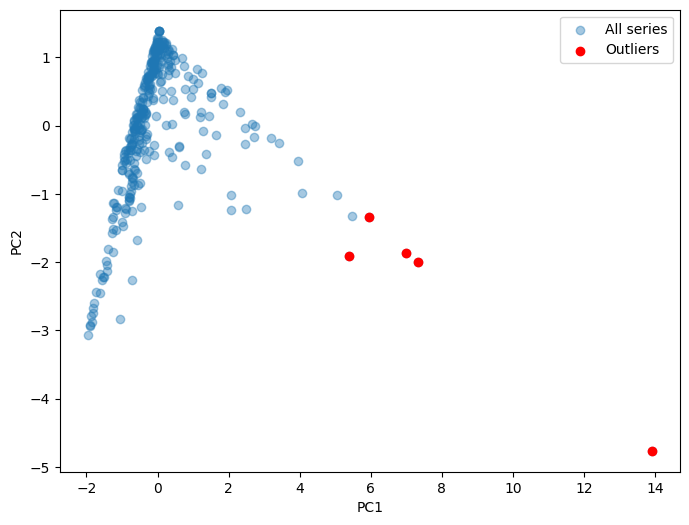

,series_id,mean,std,trend_strength,seasonal_strength,dist_from_centroid
25,Concessional_Co-payments_C10,2.484550e+07,1.838482e+07,0.988547,0.933905,14.697491
1,Concessional_Co-payments_A02,1.645504e+07,7.498596e+06,0.971145,0.933409,7.597592
24,Concessional_Co-payments_C09,1.586914e+07,7.038693e+06,0.976645,0.920340,7.234019
109,Concessional_Safety net_C10,7.388557e+06,1.017043e+07,0.950610,0.976262,6.110293
63,Concessional_Co-payments_N05,9.778107e+06,7.684177e+06,0.988094,0.633783,5.728340


In [30]:
# QUESTION 4.3
# Imports
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Collect all of the features from PBS
pbs_features = []
# Essentially a repeat of 4.2
for sid, group in pbs.groupby('series_id'):
    s = group.groupby('Month')['Cost'].sum().sort_index()
    # If the mean is 0 or s is not full, continue
    if s.mean() == 0 or len(s) < 24:
        continue
    s.index.freq = pd.infer_freq(s.index)
    stl = STL(s, period=12, robust=True).fit()
    trend, seasonal, resid = stl.trend, stl.seasonal, stl.resid
    trend_strength = max(0, 1 - np.var(resid) / np.var(trend + resid))
    seasonal_strength = max(0, 1 - np.var(resid) / np.var(seasonal + resid))
    pbs_features.append({
        'series_id': sid, 'mean': s.mean(), 'std': s.std(),
        'trend_strength': trend_strength, 'seasonal_strength': seasonal_strength
    })

# Create the data frame
pbs_feat_df = pd.DataFrame(pbs_features).dropna()

# Make the feature columns
feature_cols = ['mean', 'std', 'trend_strength', 'seasonal_strength']
X = StandardScaler().fit_transform(pbs_feat_df[feature_cols])
pca = PCA(n_components=2)
pcs = pca.fit_transform(X)
pbs_feat_df['PC1'] = pcs[:, 0]
pbs_feat_df['PC2'] = pcs[:, 1]

# Distance from the centroid in PCA space
pbs_feat_df['dist_from_centroid'] = np.sqrt(pbs_feat_df['PC1']**2 + pbs_feat_df['PC2']**2)
outliers = pbs_feat_df.sort_values('dist_from_centroid', ascending=False).head(5)

# Create the plots
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(pbs_feat_df['PC1'], pbs_feat_df['PC2'], alpha=0.4, label='All series')
ax.scatter(outliers['PC1'], outliers['PC2'], color='red', label='Outliers')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend()
plt.show()

outliers[['series_id', 'mean', 'std', 'trend_strength', 'seasonal_strength', 'dist_from_centroid']]

# ANALYSIS
# Easily the most important and standout outlier is C10, which combines a ludicrously high volume
# with high cost to literally sit in the bottom right corner of our graph. Looking into the data set,
# this section is consistent of statins, which through this period was incredibly popular for use.
# Beyond that, most points follow to make a sort of chevron, with a few outliers still lingering outside
# of the typical scope, namely A02, C09, and N05.